# Audio Emotion Recognition

This project evaluates three different approaches for detecting emotions from speech audio:

1. MFCC + SVM (classical baseline)  
2. Zero-shot Transformer model  
3. Fine-tuned Wav2Vec2 model  

All methods are compared using Accuracy, Precision, Recall, F1-score, and Confusion Matrices.

In [ ]:
!cp -r "/content/drive/MyDrive/Augnito/Emotions" "/content/Emotions"

#### Dataset Loading and Initial EDA

In [ ]:
import os
from glob import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATASET_PATH = "/content/Emotions"

In [ ]:
os.listdir(DATASET_PATH)

['Disgusted', 'Angry', 'Suprised', 'Happy', 'Sad', 'Fearful', 'Neutral']

In [ ]:
emotion_mapping = {
    "Angry": "Angry",
    "Disgusted": "Disgusted",
    "Fearful": "Fearful",
    "Happy": "Happy",
    "Neutral": "Neutral",
    "Sad": "Sad",
    "Suprised": "Surprised"
}

data = []

for folder, label in emotion_mapping.items():
    files = glob(f"{DATASET_PATH}/{folder}/*.wav")
    for f in files:
        data.append([f, label])

df = pd.DataFrame(data, columns=["path", "label"])
df.head()


,path,label
0,/content/Emotions/Angry/1022_TSI_ANG_XX.wav,Angry
1,/content/Emotions/Angry/YAF_wife_angry.wav,Angry
2,/content/Emotions/Angry/1081_ITS_ANG_XX.wav,Angry
3,/content/Emotions/Angry/1018_ITS_ANG_XX.wav,Angry
4,/content/Emotions/Angry/03-02-05-02-01-02-17.wav,Angry


In [ ]:
df["label"].value_counts()

,count
label,
Sad,2170
Happy,2167
Angry,2167
Fearful,2047
Disgusted,1863
Neutral,1795
Surprised,592


/tmp/ipython-input-4174956607.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="Set2")


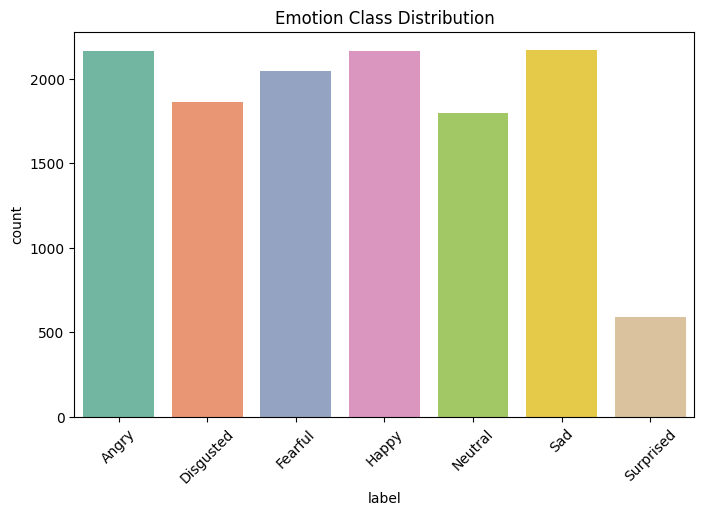

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="label", palette="Set2")
plt.title("Emotion Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
def get_duration(path):
    return librosa.get_duration(filename=path)

df["duration"] = df["path"].apply(get_duration)
df[["duration"]].describe()

/tmp/ipython-input-1429207888.py:2: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  return librosa.get_duration(filename=path)


,duration
count,12801.000000
mean,2.727174
std,0.840915
min,1.254076
25%,2.133325
50%,2.502500
75%,3.136479
max,7.138730


In [ ]:
duration_stats = (
    df.groupby("label")["duration"]
      .agg(["mean", "std"])
      .sort_values("mean")
)

duration_stats

,mean,std
label,,
Surprised,2.487691,0.721680
Neutral,2.607929,0.786582
Fearful,2.611194,0.836342
Happy,2.668230,0.903851
Angry,2.767232,0.891891
Disgusted,2.827405,0.640343
Sad,2.933362,0.895020


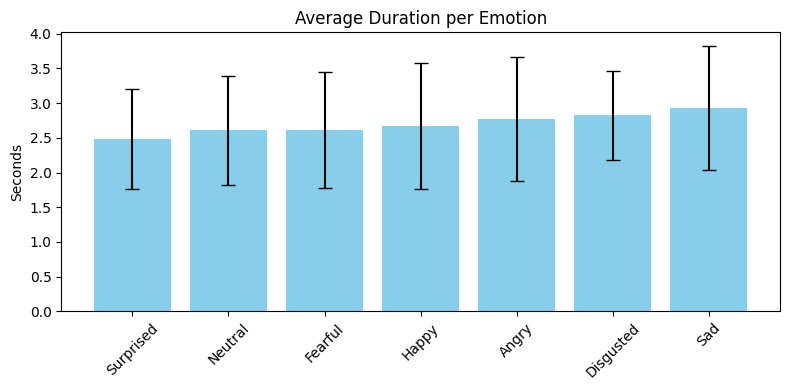

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(duration_stats.index, duration_stats["mean"],
        yerr=duration_stats["std"],
        capsize=5, color="skyblue")
plt.title("Average Duration per Emotion")
plt.ylabel("Seconds")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

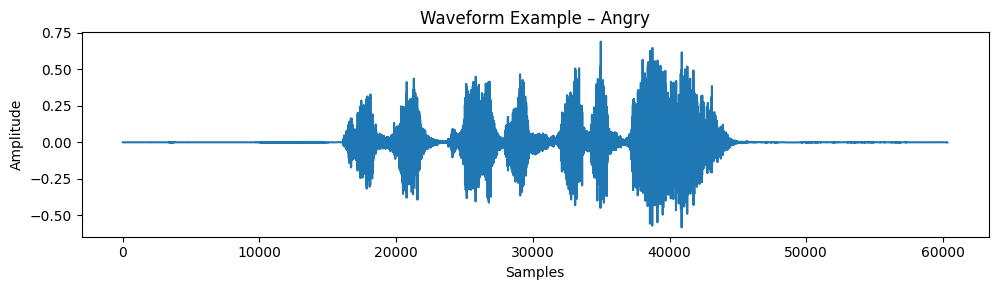

In [ ]:
sample_path = df.sample(1)["path"].values[0]
audio, sr = librosa.load(sample_path, sr=16000)

plt.figure(figsize=(10,3))
plt.plot(audio)
plt.title(f"Waveform Example – {sample_path.split('/')[-2]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

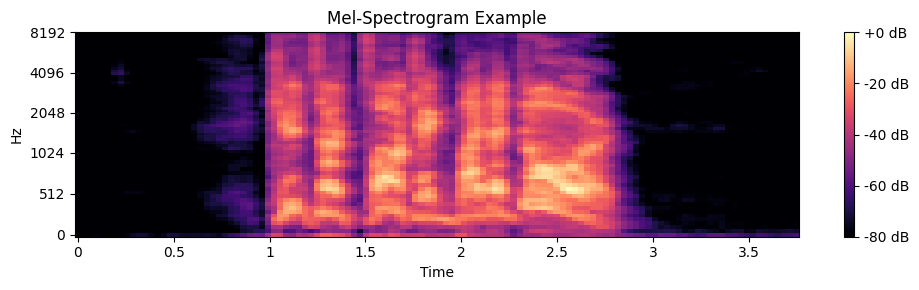

In [ ]:
spectrogram = librosa.feature.melspectrogram(
    y=audio, sr=sr, n_mels=64, fmax=8000
)
spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

plt.figure(figsize=(10,3))
librosa.display.specshow(spectrogram_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.f dB")
plt.title("Mel-Spectrogram Example")
plt.tight_layout()
plt.show()

####Train / Validation / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

len(train_df), len(val_df), len(test_df)

(8960, 1920, 1921)

In [ ]:
print("Training set distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation set distribution:")
print(val_df["label"].value_counts(normalize=True))

print("\nTest set distribution:")
print(test_df["label"].value_counts(normalize=True))

Training set distribution:
label
Sad          0.169531
Angry        0.169308
Happy        0.169308
Fearful      0.159933
Disgusted    0.145536
Neutral      0.140179
Surprised    0.046205
Name: proportion, dtype: float64

Validation set distribution:
label
Happy        0.169271
Sad          0.169271
Angry        0.169271
Fearful      0.159896
Disgusted    0.145313
Neutral      0.140625
Surprised    0.046354
Name: proportion, dtype: float64

Test set distribution:
label
Sad          0.169703
Happy        0.169183
Angry        0.169183
Fearful      0.159813
Disgusted    0.145757
Neutral      0.140031
Surprised    0.046330
Name: proportion, dtype: float64


In [ ]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [ ]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

#### Baseline Model using MFCC Features

In [ ]:
import librosa

def extract_mfcc(path, n_mfcc=40):
    audio, sr = librosa.load(path, sr=16000)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    return np.hstack([mfcc_mean, mfcc_std])

In [ ]:
from tqdm import tqdm

def build_features(df):
    X = []
    y = []

    for i, row in tqdm(df.iterrows(), total=len(df)):
        feats = extract_mfcc(row["path"])
        X.append(feats)
        y.append(row["label"])

    return np.array(X), np.array(y)

X_train, y_train = build_features(train_df)
X_val, y_val = build_features(val_df)
X_test, y_test = build_features(test_df)

100%|██████████| 1921/1921 [00:33<00:00, 58.18it/s]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=10, gamma="scale")
svm_model.fit(X_train_scaled, y_train)

SVC(C=10)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

pred_val = svm_model.predict(X_val_scaled)
pred_test = svm_model.predict(X_test_scaled)

print("Validation Accuracy:", accuracy_score(y_val, pred_val))
print("\nClassification Report (Validation):")
print(classification_report(y_val, pred_val))

print("Test Accuracy:", accuracy_score(y_test, pred_test))
print("\nClassification Report (Test):")
print(classification_report(y_test, pred_test))

Validation Accuracy: 0.725

Classification Report (Validation):
              precision    recall  f1-score   support

       Angry       0.80      0.82      0.81       325
   Disgusted       0.59      0.63      0.61       279
     Fearful       0.73      0.67      0.70       307
       Happy       0.75      0.67      0.71       325
     Neutral       0.72      0.71      0.72       270
         Sad       0.70      0.77      0.73       325
   Surprised       0.90      0.94      0.92        89

    accuracy                           0.72      1920
   macro avg       0.74      0.75      0.74      1920
weighted avg       0.73      0.72      0.72      1920

Test Accuracy: 0.7194169703279542

Classification Report (Test):
              precision    recall  f1-score   support

       Angry       0.78      0.78      0.78       325
   Disgusted       0.56      0.59      0.57       280
     Fearful       0.75      0.69      0.72       307
       Happy       0.71      0.64      0.67       325
   

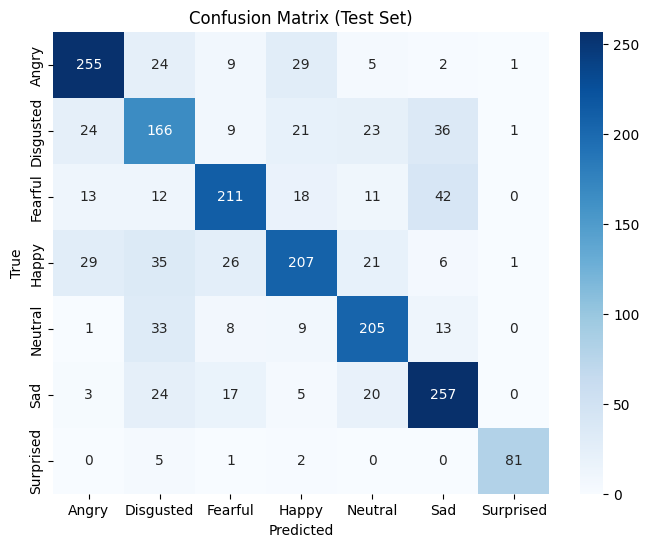

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=svm_model.classes_,
            yticklabels=svm_model.classes_)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### Zero-Shot Emotion Recognition Using a Pretrained SER Model

In [ ]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2ForSequenceClassification
import torch
import numpy as np
import librosa

model_name = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)
zero_shot_model = Wav2Vec2ForSequenceClassification.from_pretrained(model_name)
zero_shot_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Some weights of the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition were not used when initializing Wav2Vec2ForSequenceClassification: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.output.bias', 'classifier.output.weight']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition and are newly initialized: ['classifier.bias', 'classifier.weight', '

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=

In [ ]:
zero_shot_model.config.id2label

{0: 'angry',
 1: 'calm',
 2: 'disgust',
 3: 'fearful',
 4: 'happy',
 5: 'neutral',
 6: 'sad',
 7: 'surprised'}

In [ ]:
id2label = {
    0: "Angry",
    1: "Neutral",
    2: "Disgusted",
    3: "Fearful",
    4: "Happy",
    5: "Neutral",
    6: "Sad",
    7: "Surprised"
}

In [ ]:
def predict_emotion_zero_shot(path):
    audio, sr = librosa.load(path, sr=16000)

    inputs = feature_extractor(
        audio, sampling_rate=16000, return_tensors="pt", padding=True
    )

    with torch.no_grad():
        logits = zero_shot_model(**inputs).logits

    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_id = np.argmax(probs)

    return id2label[pred_id], probs

In [ ]:
from tqdm import tqdm

zero_shot_preds = []
zero_shot_probs = []

for path in tqdm(test_df["path"]):
    pred, prob = predict_emotion_zero_shot(path)
    zero_shot_preds.append(pred)
    zero_shot_probs.append(prob)

test_df["zero_shot_pred"] = zero_shot_preds

100%|██████████| 1921/1921 [1:12:46<00:00,  2.27s/it]


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Zero-shot Accuracy:", accuracy_score(test_df["label"], test_df["zero_shot_pred"]))
print("\n", classification_report(test_df["label"], test_df["zero_shot_pred"]))

Zero-shot Accuracy: 0.14836022904737117

               precision    recall  f1-score   support

       Angry       0.00      0.00      0.00       325
   Disgusted       0.05      0.04      0.05       280
     Fearful       0.04      0.02      0.03       307
       Happy       0.07      0.10      0.08       325
     Neutral       0.17      0.54      0.25       269
         Sad       0.51      0.25      0.33       326
   Surprised       0.30      0.11      0.16        89

    accuracy                           0.15      1921
   macro avg       0.16      0.15      0.13      1921
weighted avg       0.15      0.15      0.12      1921



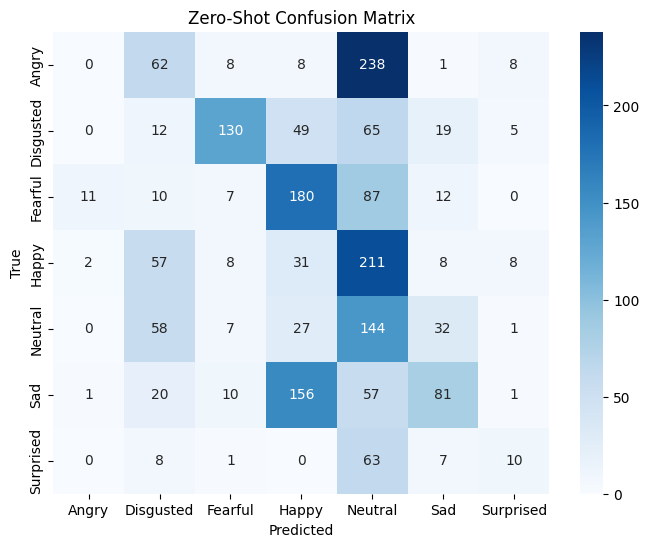

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_df["label"], test_df["zero_shot_pred"],
                      labels=["Angry","Disgusted","Fearful","Happy","Neutral","Sad","Surprised"])

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Angry","Disgusted","Fearful","Happy","Neutral","Sad","Surprised"],
            yticklabels=["Angry","Disgusted","Fearful","Happy","Neutral","Sad","Surprised"])
plt.title("Zero-Shot Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
test_df.to_csv("/content/drive/MyDrive/Augnito/test_df_zero_shot.csv", index=False)

In [ ]:
train_df.to_csv("/content/drive/MyDrive/Augnito/train_split.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/Augnito/val_split.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/Augnito/test_split.csv", index=False)

In [ ]:
df.to_csv("/content/drive/MyDrive/Augnito/full_dataset_info.csv", index=False)

In [ ]:
!cp -r "/content/drive/MyDrive/Augnito/Emotions" "/content/Emotions"

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/Augnito/train_split.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/Augnito/val_split.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/Augnito/test_df_zero_shot.csv")

In [ ]:
train_df.head(), val_df.head(), test_df.head()

(                                                path      label  duration
 0   /content/Emotions/Happy/03-01-03-01-01-02-09.wav      Happy  3.536854
 1         /content/Emotions/Happy/OAF_week_happy.wav      Happy  1.987139
 2        /content/Emotions/Happy/1074_TIE_HAP_XX.wav      Happy  2.969625
 3    /content/Emotions/Disgusted/1046_TAI_DIS_XX.wav  Disgusted  2.002000
 4  /content/Emotions/Neutral/03-02-01-01-01-02-10...    Neutral  4.904917,
                                               path      label  duration
 0      /content/Emotions/Happy/1057_IEO_HAP_MD.wav      Happy  2.275562
 1    /content/Emotions/Neutral/1049_ITS_NEU_XX.wav    Neutral  2.135438
 2  /content/Emotions/Disgusted/1074_ITH_DIS_XX.wav  Disgusted  2.836187
 3      /content/Emotions/Angry/1041_IEO_ANG_LO.wav      Angry  1.801813
 4  /content/Emotions/Disgusted/1023_WSI_DIS_XX.wav  Disgusted  2.569250,
                                                 path    label  duration  \
 0   /content/Emotions/Happy/03-01

In [ ]:
len(train_df), len(val_df), len(test_df)

(8960, 1920, 1921)

In [ ]:
test_df['zero_shot_pred'].value_counts()

,count
zero_shot_pred,
Neutral,865
Happy,451
Disgusted,227
Fearful,171
Sad,160
Surprised,33
Angry,14


In [ ]:
!pip install transformers datasets torchaudio soundfile jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.9 MB/s eta 0:00:00


#### Fine-Tuning Wav2Vec2 for Speech Emotion Recognition

In [ ]:
import torch
import librosa
import numpy as np
from datasets import Dataset
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
label_list = ['Angry','Disgusted','Fearful','Happy','Neutral','Sad','Surprised']
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}
label2id, id2label

({'Angry': 0,
  'Disgusted': 1,
  'Fearful': 2,
  'Happy': 3,
  'Neutral': 4,
  'Sad': 5,
  'Surprised': 6},
 {0: 'Angry',
  1: 'Disgusted',
  2: 'Fearful',
  3: 'Happy',
  4: 'Neutral',
  5: 'Sad',
  6: 'Surprised'})

In [ ]:
train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

In [ ]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/wav2vec2-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

In [ ]:
def preprocess(batch):
    audio, sr = librosa.load(batch["path"], sr=16000)

    out = feature_extractor(
        audio, sampling_rate=16000, return_tensors="pt"
    )

    batch["input_values"] = out.input_values[0]
    batch["labels"] = label2id[batch["label"]]
    return batch

In [ ]:
train_ds = train_ds.map(preprocess)
val_ds   = val_ds.map(preprocess)
test_ds  = test_ds.map(preprocess)

Map:   0%|          | 0/8960 [00:00<?, ? examples/s]

Map:   0%|          | 0/1920 [00:00<?, ? examples/s]

Map:   0%|          | 0/1921 [00:00<?, ? examples/s]

In [ ]:
def data_collator(batch):
    inputs = [b["input_values"] for b in batch]
    labels = [b["labels"] for b in batch]

    batch_out = feature_extractor.pad(
        {"input_values": inputs},
        return_tensors="pt"
    )

    batch_out["labels"] = torch.tensor(labels)
    return batch_out

In [ ]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=len(label_list),
    label2id=label2id,
    id2label=id2label,
)

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir="wav2vec2-ser",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=4,
    gradient_accumulation_steps=2,
    fp16=True,
    logging_steps=50,
    warmup_ratio=0.1,
    report_to="none"
)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator
)

In [ ]:
trainer.train()

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss
1,1.237200,1.123944
2,0.819500,0.801624
3,0.632800,0.721120
4,0.506200,0.617553


TrainOutput(global_step=4480, training_loss=0.9278447542871747, metrics={'train_runtime': 2318.3652, 'train_samples_per_second': 15.459, 'train_steps_per_second': 1.932, 'total_flos': 1.1900530825245668e+18, 'train_loss': 0.9278447542871747, 'epoch': 4.0})

In [ ]:
training_args.num_train_epochs = 5

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator
)

print("Continuing training from last checkpoint...\n")
train_output_5 = trainer.train(resume_from_checkpoint=True)

print("\nFinished training epoch 5.")

Continuing training from last checkpoint...



Epoch,Training Loss,Validation Loss
5,0.501700,0.612925



Finished training epoch 5.


In [ ]:
print("\nRunning Evaluation on Test Set...")

preds = trainer.predict(test_ds)
logits = preds.predictions

y_pred = np.argmax(logits, axis=-1)
y_true = test_ds["labels"]

test_acc = accuracy_score(y_true, y_pred)
print("\nTest Accuracy:", test_acc)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_list))


Running Evaluation on Test Set...



Test Accuracy: 0.7902134305049453

Classification Report:

              precision    recall  f1-score   support

       Angry       0.78      0.90      0.84       325
   Disgusted       0.85      0.67      0.75       280
     Fearful       0.78      0.68      0.73       307
       Happy       0.82      0.73      0.77       325
     Neutral       0.77      0.92      0.84       269
         Sad       0.72      0.80      0.76       326
   Surprised       0.95      0.91      0.93        89

    accuracy                           0.79      1921
   macro avg       0.81      0.80      0.80      1921
weighted avg       0.79      0.79      0.79      1921




Generating Confusion Matrix...


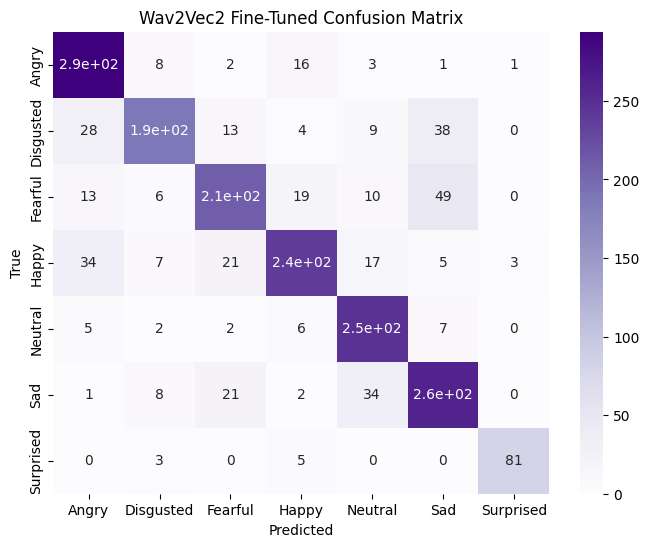

In [ ]:
print("\nGenerating Confusion Matrix...")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Purples",
            xticklabels=label_list, yticklabels=label_list)
plt.title("Wav2Vec2 Fine-Tuned Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Plotting Training & Validation Loss Curves...


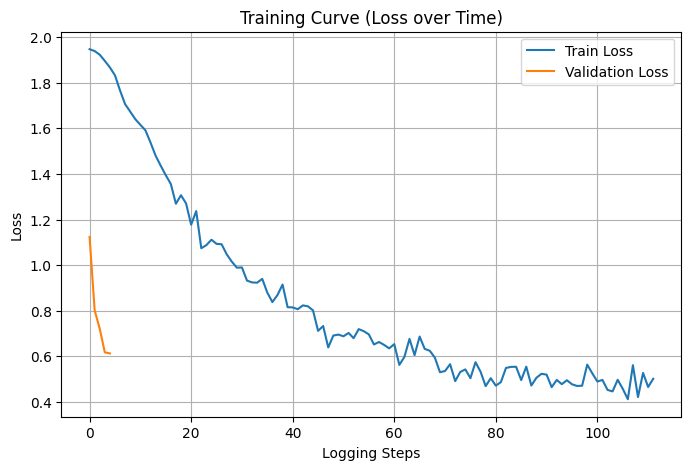

In [ ]:
print("\nPlotting Training & Validation Loss Curves...")

logs = trainer.state.log_history

# Extract training & validation losses
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss  = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Logging Steps")
plt.ylabel("Loss")
plt.title("Training Curve (Loss over Time)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
save_dir = "/content/drive/MyDrive/Augnito/Wav2Vec2_SER_Model"

model.save_pretrained(save_dir)
feature_extractor.save_pretrained(save_dir)

print("Model saved to:", save_dir)

Model saved to: /content/drive/MyDrive/Augnito/Wav2Vec2_SER_Model


In [ ]:
!cp -r wav2vec2-ser "/content/drive/MyDrive/Augnito/Wav2Vec2_Checkpoints"

In [ ]:
import json

state_path = "/content/drive/MyDrive/Augnito/Wav2Vec2_Checkpoints/checkpoint-5600/trainer_state.json"

with open(state_path, "r") as f:
    state = json.load(f)

logs = state["log_history"]

In [ ]:
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss  = [x["eval_loss"] for x in logs if "eval_loss" in x]

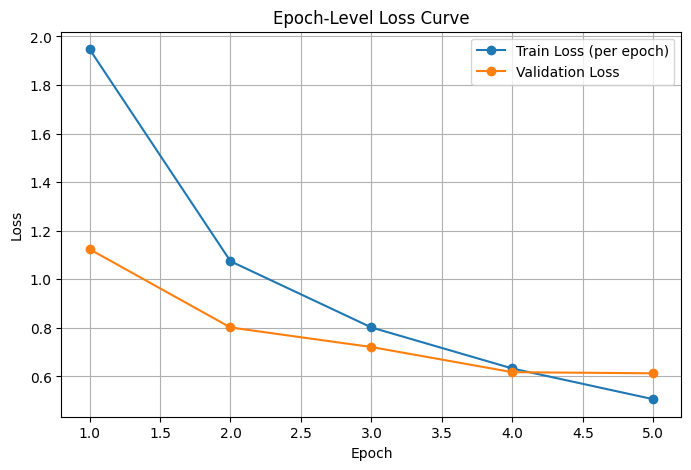

In [ ]:
steps_per_epoch = len(train_loss) // len(eval_loss)

train_loss_epoch = [
    train_loss[i * steps_per_epoch] for i in range(len(eval_loss))
]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(eval_loss)+1), train_loss_epoch, marker="o",
         label="Train Loss (per epoch)")
plt.plot(range(1, len(eval_loss)+1), eval_loss, marker="o",
         label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.title("Epoch-Level Loss Curve")
plt.show()

#### Comparison of All Methods

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["MFCC + SVM", "Zero-Shot Transformer", "Fine-Tuned Wav2Vec2"],
    "Accuracy": [0.7194, 0.1483, 0.7902],
    "Macro F1": [0.74, 0.13, 0.80]
})

comparison_df

,Model,Accuracy,Macro F1
0,MFCC + SVM,0.7194,0.74
1,Zero-Shot Transformer,0.1483,0.13
2,Fine-Tuned Wav2Vec2,0.7902,0.80
